# Bias-Corrected SARIMA Models and Final Validation

## Purpose
Corrects the systematic prediction bias identified in `sarima_residuals.ipynb` for two candidate SARIMA configurations, and evaluates each against the held-out validation set. The trained model and bias constant for the chosen configuration are persisted to disk for production use.

The bias is estimated as the mean of the training residuals from `sarima_residuals.ipynb` and added to every forecast. The ACF and PACF of the corrected residuals are then inspected to confirm no autocorrelation structure remains.

Two candidates are evaluated in sequence:
- **Candidate 1:** SARIMA(1,0,0)(2,0,0,12), bias = −421.896172
- **Candidate 2:** SARIMA(2,0,1)(1,1,0,12), bias = −58.604374

## Inputs
- `data/dataset.csv` — Training dataset (93 monthly observations)
- `data/validation.csv` — Held-out validation set (12 observations, never seen during development)

## Outputs
- `models/sarima_model.pkl` — Serialised `SARIMAXResults` object (final fit on full training history)
- `models/sarima_bias.npy` — NumPy array containing the scalar bias correction constant
- Inline: training RMSE, corrected residual statistics, ACF/PACF plots, and final validation RMSE with a plot of predictions vs actuals

In [15]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX, SARIMAXResults
from matplotlib import pyplot as plt
from sklearn.metrics import mean_squared_error
from math import sqrt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import numpy as np

## Load Training Data

In [16]:
series = pd.read_csv('data/dataset.csv', index_col=0, parse_dates=True).iloc[:, 0]
series.head()

Month
1964-01-01    2815
1964-02-01    2672
1964-03-01    2755
1964-04-01    2721
1964-05-01    2946
Name: Sales, dtype: int64

## Train / Test Split

In [17]:
# prepare data
X = series.values
X = X.astype('float64')
train_size = int(len(X) * 0.50)
train, test = X[0:train_size], X[train_size:]

## Candidate 1: Walk-Forward Validation with Bias Correction — SARIMA(1,0,0)(2,0,0,12)

The bias constant (`−421.896172`) was estimated as the mean of the residuals from `sarima_residuals.ipynb` for this configuration. It is added to every forecast before the prediction is recorded.

In [18]:
# walk-forward validation
# Set bias to the mean residual found in sarima_residuals.ipynb
# If the residual mean is near zero, set bias = 0.0
bias = -421.896172  # <-- update after inspecting sarima_residuals.ipynb
order = (1, 0, 0)
seasonal_order = (2, 0, 0, 12)  # <-- update with best order from grid_sarima.ipynb
history = [x for x in train]
predictions = list()
for i in range(len(test)):
    model = SARIMAX(history, order=order, seasonal_order=seasonal_order,
                    enforce_stationarity=False, enforce_invertibility=False)
    model_fit = model.fit(disp=False)
    yhat = bias + model_fit.forecast()[0]
    predictions.append(yhat)
    obs = test[i]
    history.append(obs)

## Candidate 1: Training Set RMSE

The in-sample RMSE after bias correction. Compare this to the uncorrected SARIMA, ARIMA, and persistence baseline RMSEs to quantify the improvement.

In [19]:
# report performance on test split
rmse = sqrt(mean_squared_error(test, predictions))
print('RMSE: %.3f' % rmse)

RMSE: 767.723


## Candidate 1: Corrected Residual Summary Statistics

The residual mean should now be near zero, confirming the bias has been successfully removed.

In [20]:
# residual summary after bias correction
residuals = [test[i] - predictions[i] for i in range(len(test))]
residuals = pd.DataFrame(residuals)
print(residuals.describe())

                  0
count  4.700000e+01
mean   2.559028e-08
std    7.760233e+02
min   -1.887173e+03
25%   -2.979246e+02
50%    3.552819e+01
75%    6.001748e+02
max    1.663391e+03


## Candidate 1: Residual Distribution

A histogram and KDE of the corrected residuals. Approximately symmetric and centred at zero would indicate no remaining bias.

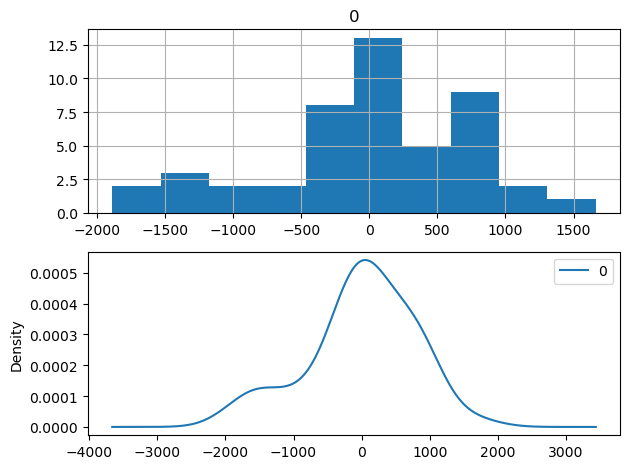

In [21]:
# residual distribution
plt.figure()
plt.subplot(211)
residuals.hist(ax=plt.gca())
plt.subplot(212)
residuals.plot(kind='kde', ax=plt.gca())
plt.tight_layout()
plt.show()

## Candidate 1: Residual ACF and PACF

Inspect the autocorrelation structure of the corrected residuals. No significant spikes beyond the confidence bands would indicate the model has captured the available signal and the residuals are consistent with white noise.

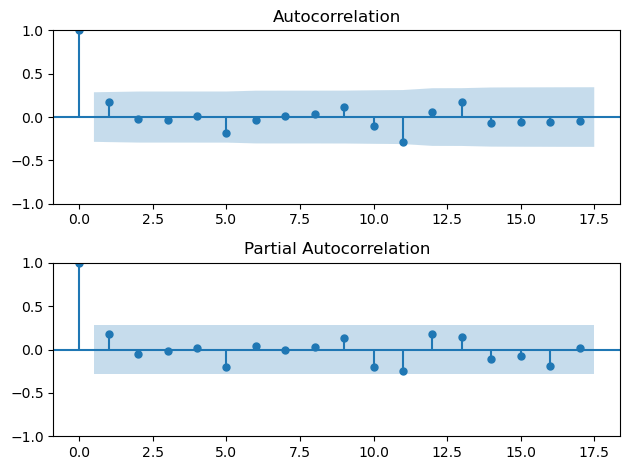

In [22]:
# residual autocorrelation — confirm no structure remains
plt.figure()
plt.subplot(211)
plot_acf(residuals, ax=plt.gca())
plt.subplot(212)
plot_pacf(residuals, ax=plt.gca())
plt.tight_layout()
plt.show()

## Candidate 1: Persist Model and Bias Constant

Serialise the final fitted `SARIMAXResults` object to `models/sarima_model.pkl` and save the bias scalar to `models/sarima_bias.npy`. These two artefacts together constitute the complete deployable model for this candidate.

In [23]:
# save model and bias for validation
model_fit.save('models/sarima_model.pkl')
np.save('models/sarima_bias.npy', [bias])

## Candidate 1: Load Model and Generate Next-Step Forecast

Demonstrate the complete prediction pipeline using the saved artefacts: load the model and bias, produce a one-step-ahead forecast, and apply the bias correction. This is the exact code path that would be used in production.

In [24]:
# one-step forecast beyond training data
model_fit = SARIMAXResults.load('models/sarima_model.pkl')
bias = float(np.load('models/sarima_bias.npy')[0])
yhat = bias + float(model_fit.forecast()[0])
print('Predicted: %.3f' % yhat)

Predicted: 5302.186


## Load Held-Out Validation Data

Load the 12-month validation set that was held back at the very start of the project. This is the first and only time validation data is used — it has had no influence on any modelling decisions.

In [25]:
# load validation set and run rolling forecasts
X = series.values.astype('float64')
history = [x for x in X]
validation = pd.read_csv('data/validation.csv', index_col=0, parse_dates=True).iloc[:, 0]
y = validation.values.astype('float64')
validation.head()

Month
1971-10-01     6981
1971-11-01     9851
1971-12-01    12670
1972-01-01     4348
1972-02-01     3564
Name: Sales, dtype: int64

## Candidate 1: First Validation Forecast (from Saved Model)

Generate the first validation forecast using the persisted model object, then append the true observation to history. Subsequent forecasts re-fit the model to keep it current, matching the walk-forward protocol used during development.

In [26]:
# first forecast (from saved model)
predictions = list()
yhat = bias + float(model_fit.forecast()[0])
predictions.append(yhat)
history.append(y[0])
print('>Predicted=%.3f, Expected=%.3f' % (yhat, y[0]))

>Predicted=5302.186, Expected=6981.000


## Candidate 1: Rolling Validation Forecasts

Walk forward through the remaining 11 validation observations, re-fitting SARIMA(1,0,0)(2,0,0,12) at each step with the full updated history and applying the bias correction to every forecast.

In [27]:
# rolling forecasts over validation set
for i in range(1, len(y)):
    model = SARIMAX(history, order=order, seasonal_order=seasonal_order,
                    enforce_stationarity=False, enforce_invertibility=False)
    model_fit = model.fit(disp=False)
    yhat = bias + model_fit.forecast()[0]
    predictions.append(yhat)
    obs = y[i]
    history.append(obs)
    print('>Predicted=%.3f, Expected=%.3f' % (yhat, obs))

>Predicted=10987.102, Expected=9851.000
>Predicted=13819.193, Expected=12670.000
>Predicted=2405.431, Expected=4348.000
>Predicted=3084.498, Expected=3564.000
>Predicted=3900.838, Expected=4577.000
>Predicted=4338.845, Expected=4788.000
>Predicted=4170.406, Expected=4618.000
>Predicted=4479.383, Expected=5312.000
>Predicted=4536.474, Expected=4298.000
>Predicted=1219.313, Expected=1413.000
>Predicted=5537.250, Expected=5877.000


## Candidate 1: Final Validation Performance

Compute and report the RMSE on the held-out validation set. Plot the actual validation values against the bias-corrected predictions to visually assess forecast quality across the full 12-month horizon.

RMSE: 965.903


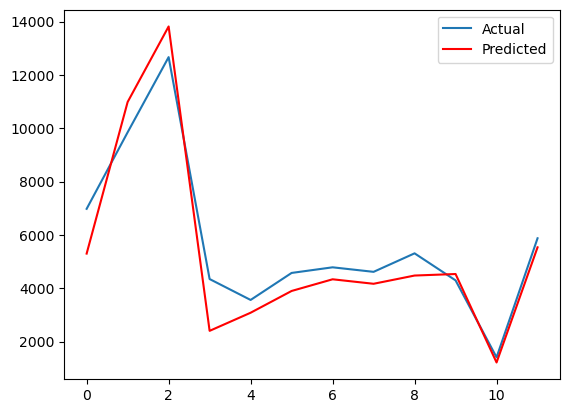

In [28]:
# report validation performance
rmse = sqrt(mean_squared_error(y, predictions))
print('RMSE: %.3f' % rmse)
plt.plot(y, label='Actual')
plt.plot(predictions, color='red', label='Predicted')
plt.legend()
plt.show()

---

## Candidate 2: Walk-Forward Validation with Bias Correction — SARIMA(2,0,1)(1,1,0,12)

The bias constant (`−58.604374`) was estimated as the mean of the residuals from `sarima_residuals.ipynb` for this configuration. `D=1` is handled internally by `SARIMAX`; the bias is managed explicitly rather than being absorbed into the model's constant.

In [29]:
# walk-forward validation
# Set bias to the mean residual found in sarima_residuals.ipynb
# If the residual mean is near zero, set bias = 0.0
bias = -58.604374  # <-- update after inspecting sarima_residuals.ipynb
order = (2, 0, 1)
seasonal_order = (1, 1, 0, 12)  # <-- update with best order from grid_sarima.ipynb
history = [x for x in train]
predictions = list()
for i in range(len(test)):
    model = SARIMAX(history, order=order, seasonal_order=seasonal_order,
                    enforce_stationarity=False, enforce_invertibility=False)
    model_fit = model.fit(disp=False)
    yhat = bias + model_fit.forecast()[0]
    predictions.append(yhat)
    obs = test[i]
    history.append(obs)

## Candidate 2: Training Set RMSE

In [30]:
# report performance on test split
rmse = sqrt(mean_squared_error(test, predictions))
print('RMSE: %.3f' % rmse)

RMSE: 900.243


## Candidate 2: Corrected Residual Summary Statistics

The residual mean should now be near zero, confirming the bias has been successfully removed for this configuration.

In [31]:
# residual summary after bias correction
residuals = [test[i] - predictions[i] for i in range(len(test))]
residuals = pd.DataFrame(residuals)
print(residuals.describe())

                  0
count  4.700000e+01
mean   4.706958e-07
std    9.099756e+02
min   -2.423998e+03
25%   -3.829952e+02
50%    3.346744e+01
75%    5.495765e+02
max    2.456500e+03


## Candidate 2: Residual Distribution

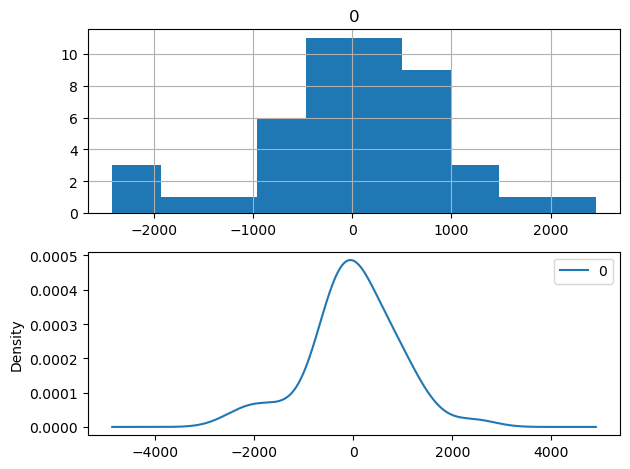

In [32]:
# residual distribution
plt.figure()
plt.subplot(211)
residuals.hist(ax=plt.gca())
plt.subplot(212)
residuals.plot(kind='kde', ax=plt.gca())
plt.tight_layout()
plt.show()

## Candidate 2: Residual ACF and PACF

Inspect the autocorrelation structure of the corrected residuals for Candidate 2. Compare to Candidate 1 to determine which configuration produces cleaner residuals.

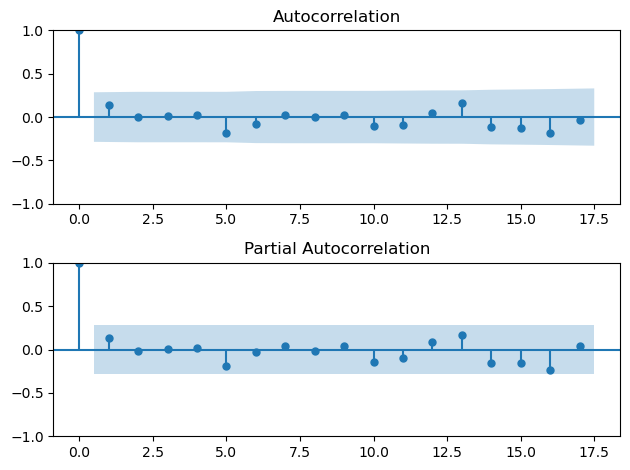

In [33]:
# residual autocorrelation — confirm no structure remains
plt.figure()
plt.subplot(211)
plot_acf(residuals, ax=plt.gca())
plt.subplot(212)
plot_pacf(residuals, ax=plt.gca())
plt.tight_layout()
plt.show()

## Candidate 2: Persist Model and Bias Constant

Overwrites `models/sarima_model.pkl` and `models/sarima_bias.npy` with the Candidate 2 artefacts. Ensure validation performance is compared across both candidates before committing to a final selection.

In [34]:
# save model and bias for validation
model_fit.save('models/sarima_model.pkl')
np.save('models/sarima_bias.npy', [bias])

## Candidate 2: Load Model and Generate Next-Step Forecast

In [35]:
# one-step forecast beyond training data
model_fit = SARIMAXResults.load('models/sarima_model.pkl')
bias = float(np.load('models/sarima_bias.npy')[0])
yhat = bias + float(model_fit.forecast()[0])
print('Predicted: %.3f' % yhat)

Predicted: 5184.077


## Load Held-Out Validation Data

In [36]:
# load validation set and run rolling forecasts
X = series.values.astype('float64')
history = [x for x in X]
validation = pd.read_csv('data/validation.csv', index_col=0, parse_dates=True).iloc[:, 0]
y = validation.values.astype('float64')
validation.head()

Month
1971-10-01     6981
1971-11-01     9851
1971-12-01    12670
1972-01-01     4348
1972-02-01     3564
Name: Sales, dtype: int64

## Candidate 2: First Validation Forecast (from Saved Model)

In [37]:
# first forecast (from saved model)
predictions = list()
yhat = bias + float(model_fit.forecast()[0])
predictions.append(yhat)
history.append(y[0])
print('>Predicted=%.3f, Expected=%.3f' % (yhat, y[0]))

>Predicted=5184.077, Expected=6981.000


## Candidate 2: Rolling Validation Forecasts

Walk forward through the remaining 11 validation observations, re-fitting SARIMA(2,0,1)(1,1,0,12) at each step with the full updated history and applying the bias correction to every forecast.

In [38]:
# rolling forecasts over validation set
for i in range(1, len(y)):
    model = SARIMAX(history, order=order, seasonal_order=seasonal_order,
                    enforce_stationarity=False, enforce_invertibility=False)
    model_fit = model.fit(disp=False)
    yhat = bias + model_fit.forecast()[0]
    predictions.append(yhat)
    obs = y[i]
    history.append(obs)
    print('>Predicted=%.3f, Expected=%.3f' % (yhat, obs))

>Predicted=10325.552, Expected=9851.000
>Predicted=13287.459, Expected=12670.000
>Predicted=3215.288, Expected=4348.000
>Predicted=3284.356, Expected=3564.000
>Predicted=4082.860, Expected=4577.000
>Predicted=4499.141, Expected=4788.000
>Predicted=4402.917, Expected=4618.000
>Predicted=4633.811, Expected=5312.000
>Predicted=4665.117, Expected=4298.000
>Predicted=1600.366, Expected=1413.000
>Predicted=5610.162, Expected=5877.000


## Candidate 2: Final Validation Performance

Compute and report the RMSE on the held-out validation set. Compare this against Candidate 1's validation RMSE to select the better-performing configuration for deployment.

RMSE: 722.929


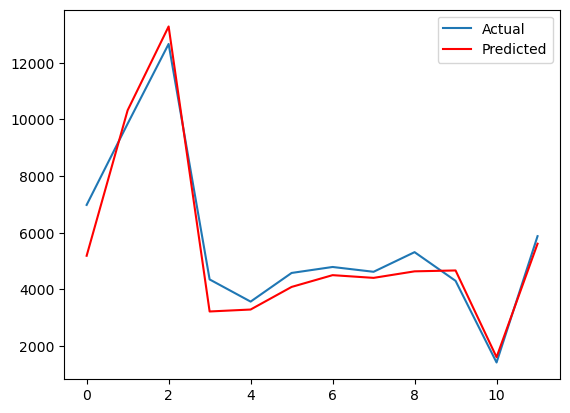

In [39]:
# report validation performance
rmse = sqrt(mean_squared_error(y, predictions))
print('RMSE: %.3f' % rmse)
plt.plot(y, label='Actual')
plt.plot(predictions, color='red', label='Predicted')
plt.legend()
plt.show()